C:\Users\qq\AppData\Local\Temp\ipykernel_12452\4044179476.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_perf, x='부서', y='월별 매출액', palette='Blues_d')
C:\Users\qq\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


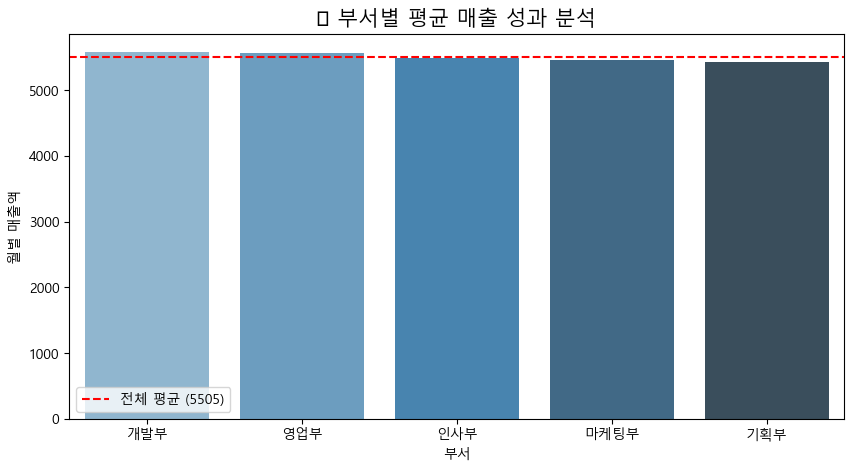


📢 [데이터 기반 최종 의사결정 전략 보고서]
📊 [참고 데이터] 지역별 매출 전체 현황


,지역,매출 합계,매출 평균
4,서울,11303631,5522.047386
2,대전,10996224,5422.201183
1,광주,10974848,5542.852525
0,경기,10952984,5529.017668
3,부산,10817617,5507.951629


------------------------------------------------------------
✅ [최우수 성과] '개발부' (전체 평균 대비 1.3% 상회)
👉 전략: 해당 부서의 성공 모델을 전사 표준으로 채택
------------------------------------------------------------
✅ [안정적 성과] 모든 지역이 평균 목표치를 달성 중입니다.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
df = pd.read_csv('final_analysis_data.csv')
overall_avg = df['월별 매출액'].mean() # 전체 평균

# 2. 지역별/부서별 통계 산출
dept_perf = df.groupby('부서')['월별 매출액'].mean().sort_values(ascending=False).reset_index()
region_stats = df.groupby('지역별 매출')['월별 매출액'].agg(['sum', 'mean']).reset_index()
region_stats.columns = ['지역', '매출 합계', '매출 평균']

# ---------------------------------------------------------
# [시각화] 부서별 성과 비교 그래프
plt.figure(figsize=(10, 5))
sns.barplot(data=dept_perf, x='부서', y='월별 매출액', palette='Blues_d')
plt.axhline(overall_avg, color='red', linestyle='--', label=f'전체 평균 ({overall_avg:.0f})')
plt.title('🏢 부서별 평균 매출 성과 분석', fontsize=15)
plt.legend()
plt.show()
# ---------------------------------------------------------

# 3. 데이터 기반 의사결정 보고서 출력
print("\n" + "="*60)
print("📢 [데이터 기반 최종 의사결정 전략 보고서]")
print("="*60)

# [추가된 부분] 지역별 전체 현황 표 출력
print("📊 [참고 데이터] 지역별 매출 전체 현황")
display(region_stats.sort_values(by='매출 합계', ascending=False)) 
print("-" * 60)

# 인사이트 1: 최우수 부서 분석
top_dept = dept_perf.iloc[0]
efficiency = (top_dept['월별 매출액'] / overall_avg - 1) * 100
print(f"✅ [최우수 성과] '{top_dept['부서']}' (전체 평균 대비 {efficiency:.1f}% 상회)")
print(f"👉 전략: 해당 부서의 성공 모델을 전사 표준으로 채택")

print("-" * 60)

# 인사이트 2: 위기 관리 지역 분석
low_regions = region_stats[region_stats['매출 평균'] < overall_avg * 0.9]

if not low_regions.empty:
    print(f"⚠️ [위기 관리] 성과 미달 지역: {list(low_regions['지역'])}")
    print(f"👉 전략: 해당 지역 대상 '타겟 마케팅 프로모션' 15% 추가 예산 배정")
else:
    print("✅ [안정적 성과] 모든 지역이 평균 목표치를 달성 중입니다.")

print("="*60)